# Feature Engineering & Return Analysis

## Objectives
1. **Return transformations**: Understand log vs arithmetic returns and their properties
2. **Volatility normalization**: Learn why and how to normalize by volatility
3. **Feature generation**: Build 12 candidate features across 4 families
4. **Statistical properties**: Test stationarity and visualize distributions

## Key Concepts

**Log Returns (Additivity Property)**:
- $r_{t} = \ln(P_t / P_{t-1})$
- Multi-period: $r_{t \to t+n} = r_t + r_{t+1} + ... + r_{t+n-1}$
- Closer to normal distribution than arithmetic returns

**Z-Score Interpretation**:
- $z = (x - \mu) / \sigma$
- $|z| < 1$: Within 1σ (68% of data)
- $|z| < 2$: Within 2σ (95% of data)
- $|z| > 3$: Extreme outlier (0.3% of data)

**Why Volatility Normalization?**
- Makes signals regime-invariant
- In high-vol periods, same absolute move has lower z-score
- Prevents false signals during market stress

In [1]:
# Setup
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Import project modules
from src.data.forensics import load_csv_data
from src.features import (
    FeatureLibrary,
    compute_log_returns,
    compute_rolling_vol,
    compute_zscore,
)

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Imports successful")

✓ Imports successful


## 1. Load Data

Load USDJPY H1 (60-minute) data from raw CSV.

In [2]:
# Load USDJPY H1 data
df = load_csv_data(Path.cwd().parent / 'data/raw/USDJPY_10yr_1h_dukascopy.csv')

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()


Data shape: (12231, 5)
Date range: 2024-03-11 20:00:00+00:00 to 2026-03-10 17:00:00+00:00

Columns: ['open', 'high', 'low', 'close', 'volume']

First 5 rows:


,open,high,low,close,volume
datetime,,,,,
2024-03-11 20:00:00+00:00,146.964005,146.979996,146.917999,146.936996,0
2024-03-11 21:00:00+00:00,146.921005,146.973999,146.847000,146.964005,0
2024-03-11 22:00:00+00:00,146.968002,146.968994,146.891998,146.947006,0
2024-03-11 23:00:00+00:00,146.945999,146.951996,146.710007,146.731003,0
2024-03-12 00:00:00+00:00,146.737000,146.882996,146.613007,146.869003,0


## 2. Theory: Log Returns vs Arithmetic Returns

**Arithmetic Returns**:
$$r_t^{arith} = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

**Log Returns**:
$$r_t^{log} = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

**Key Property — Additivity**:
$$r_{1 \to 3}^{log} = r_1^{log} + r_2^{log} + r_3^{log}$$

This makes log returns ideal for:
- Multi-period aggregation
- Statistical modeling (closer to normal distribution)
- Avoiding compounding errors

**Portfolio Property**:
- Arithmetic returns: $r_p = w_1 r_1 + w_2 r_2$ (portfolio additivity)
- Log returns: $r_p^{total} = \sum r_i$ (time additivity)

For small returns, they are approximately equal: $r^{log} \approx r^{arith}$

In [3]:
# Compute log returns
log_returns = compute_log_returns(df['close'])

print(f"Log returns computed: {len(log_returns)} periods")
print(f"Non-null values: {log_returns.notna().sum()}")
print(f"Mean: {log_returns.mean():.6f}")
print(f"Std: {log_returns.std():.6f}")
print(f"\nFirst 10 non-null values:")
log_returns.dropna().head(10)

Log returns computed: 12231 periods
Non-null values: 12230
Mean: 0.000006
Std: 0.001290

First 10 non-null values:


datetime
2024-03-11 21:00:00+00:00    0.000184
2024-03-11 22:00:00+00:00   -0.000116
2024-03-11 23:00:00+00:00   -0.001471
2024-03-12 00:00:00+00:00    0.000940
2024-03-12 01:00:00+00:00    0.000442
2024-03-12 02:00:00+00:00    0.003227
2024-03-12 03:00:00+00:00   -0.000129
2024-03-12 04:00:00+00:00   -0.000054
2024-03-12 05:00:00+00:00    0.000916
2024-03-12 06:00:00+00:00   -0.000807
Name: close, dtype: float64

## 3. Theory: Volatility Normalization & Z-Scores

**Why Normalize by Volatility?**

Raw returns are non-comparable across regimes:
- A 0.5% move in low-vol regime → significant
- A 0.5% move in high-vol regime → noise

**Z-Score Formula**:
$$z_t = \frac{x_t - \mu_t}{\sigma_t}$$

where $\mu_t$ and $\sigma_t$ are computed over a rolling window.

**Interpretation**:
- $|z| < 1$: Within 1 standard deviation (68% of data under normal distribution)
- $1 < |z| < 2$: Within 2 standard deviations (95% of data)
- $|z| > 2$: Within 3 standard deviations (99.7% of data)
- $|z| > 3$: Extreme outlier (0.3% of data)

**Key Benefit**: Z-scores make signals regime-invariant. A z-score of 2 means "2 standard deviations above normal" regardless of whether the market is calm or volatile.

## 4. Generate 12 Candidate Features

We'll create features across **4 families**:

### Momentum Features
- `mom_5`: 5-period momentum (log return over 5 bars)
- `mom_10`: 10-period momentum
- `mom_20`: 20-period momentum

### Volatility Features
- `vol_10`: 10-period rolling volatility
- `vol_20`: 20-period rolling volatility
- `vol_50`: 50-period rolling volatility

### Mean-Reversion Features
- `zscore_20`: 20-period z-score of returns
- `zscore_50`: 50-period z-score of returns
- `distance_from_ma_20`: Z-scored distance from 20-period moving average

### Microstructure Features
- `range`: Bar range (high - low)
- `true_range`: True range accounting for gaps
- `close_position`: Where close occurred within bar range [0,1]

In [4]:
# Initialize feature library
lib = FeatureLibrary()

# Create feature DataFrame
features = pd.DataFrame(index=df.index)

# Momentum features (3)
features['mom_5'] = lib.momentum(df['close'], period=5)
features['mom_10'] = lib.momentum(df['close'], period=10)
features['mom_20'] = lib.momentum(df['close'], period=20)

# Volatility features (3)
features['vol_10'] = lib.volatility(log_returns, window=10)
features['vol_20'] = lib.volatility(log_returns, window=20)
features['vol_50'] = lib.volatility(log_returns, window=50)

# Mean-reversion features (3)
features['zscore_20'] = compute_zscore(log_returns, window=20)
features['zscore_50'] = compute_zscore(log_returns, window=50)
features['distance_from_ma_20'] = lib.distance_from_ma(df['close'], window=20)

# Microstructure features (3)
features['range'] = lib.range_feature(df['high'], df['low'])
features['true_range'] = lib.true_range(df['high'], df['low'], df['close'])
features['close_position'] = lib.close_position(df['high'], df['low'], df['close'])

print(f"Features generated: {features.shape}")
print(f"\nSummary statistics:")
features.describe()

Features generated: (12231, 12)

Summary statistics:


,mom_5,mom_10,mom_20,vol_10,vol_20,vol_50,zscore_20,zscore_50,distance_from_ma_20,range,true_range,close_position
count,12226.000000,12221.000000,12211.000000,12221.000000,12211.000000,12181.000000,12211.000000,12181.000000,12193.000000,12231.000000,12231.000000,12201.000000
mean,0.000029,0.000057,0.000111,0.001077,0.001121,0.001167,-0.006044,-0.004335,0.139352,0.256333,0.258062,0.524872
std,0.002903,0.004144,0.005943,0.000705,0.000634,0.000551,0.983854,0.998864,1.577660,0.197123,0.200128,0.287444
min,-0.024197,-0.028879,-0.046189,0.000109,0.000158,0.000240,-4.235217,-6.800933,-6.384220,0.000000,0.000000,0.000000
25%,-0.001280,-0.001938,-0.002823,0.000659,0.000736,0.000807,-0.573086,-0.519446,-0.908435,0.141998,0.142990,0.274010
50%,0.000116,0.000178,0.000434,0.000928,0.000981,0.001052,-0.004789,0.000844,0.157194,0.212006,0.212006,0.536031
75%,0.001436,0.002199,0.003355,0.001281,0.001333,0.001372,0.578842,0.541255,1.203459,0.309006,0.310989,0.785396
max,0.022053,0.021352,0.024884,0.007542,0.005517,0.003832,4.158370,6.424521,5.872117,4.600006,4.600006,1.000000


## 5. Distribution Analysis

**Why This Matters**:
- FX features often exhibit **heavy tails** (fat-tailed distributions)
- **Regime shifts** can cause multiple modes in the distribution
- **Skewness** indicates directional bias
- These properties affect risk modeling and strategy design

We'll visually inspect each feature's distribution to detect:
1. Normality (or lack thereof)
2. Outliers and extreme values
3. Multi-modal patterns (regime changes)

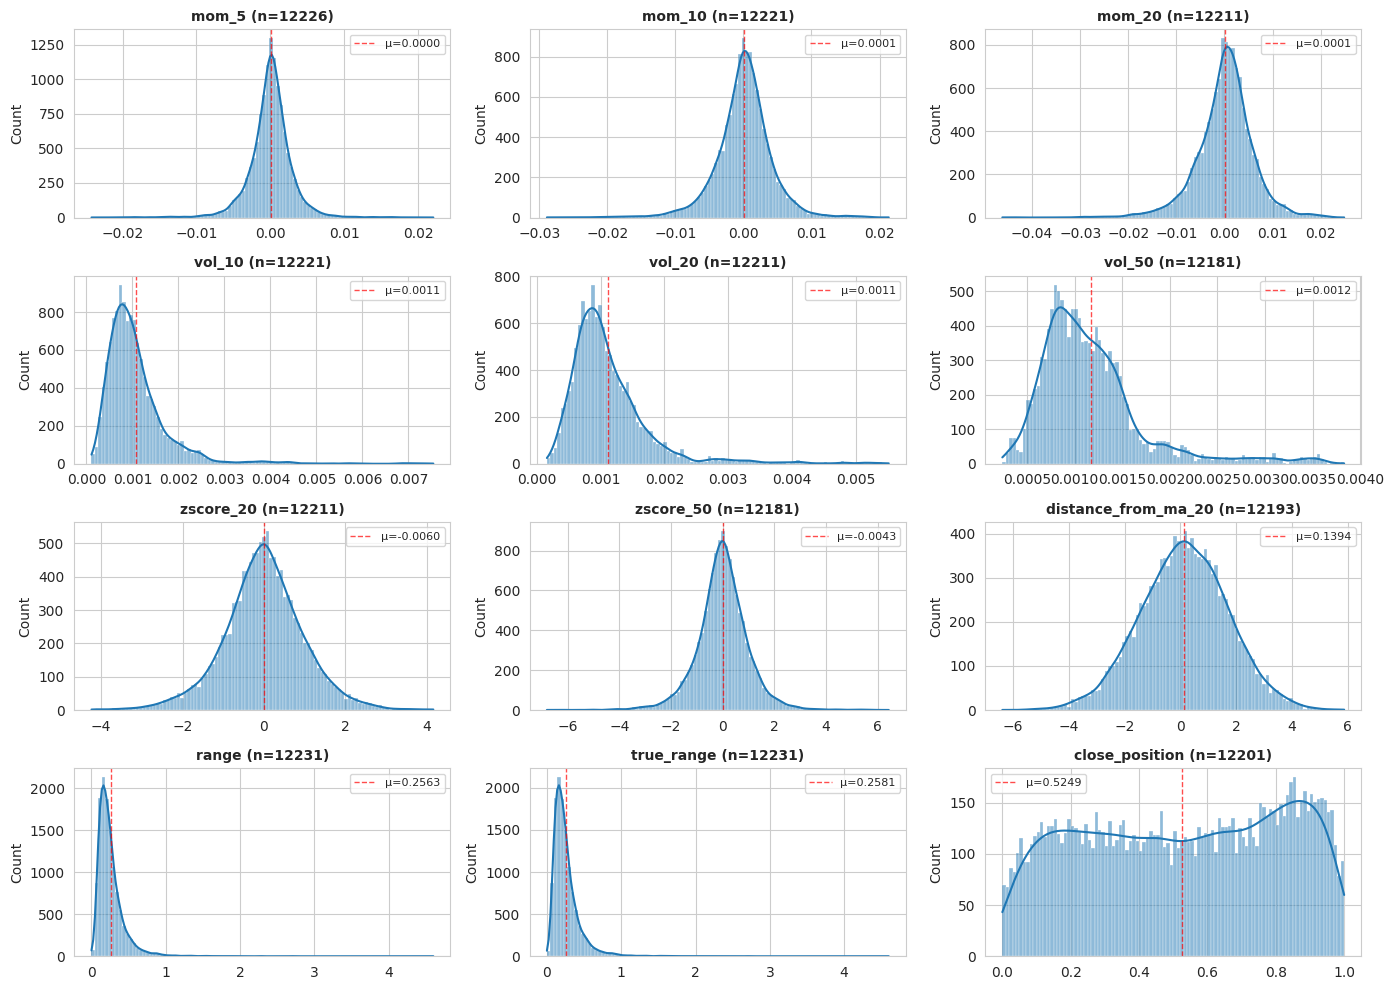

✓ Distribution plots generated


In [5]:
# Plot distributions for all 12 features
fig, axes = plt.subplots(4, 3, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(features.columns):
    data = features[col].dropna()
    
    sns.histplot(data, bins=100, ax=axes[idx], kde=True)
    axes[idx].set_title(f'{col} (n={len(data)})', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('')
    
    # Add mean and std to plot
    mean_val = data.mean()
    std_val = data.std()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'μ={mean_val:.4f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Distribution plots generated")

## 6. Stationarity Testing

**Augmented Dickey-Fuller (ADF) Test**:
- **Null hypothesis**: Series has a unit root (non-stationary)
- **Alternative hypothesis**: Series is stationary

**Interpretation**:
- $p < 0.05$: Reject null → **stationary**
- $p > 0.05$: Fail to reject null → **non-stationary**

**Why This Matters**:
- Most price-based features are non-stationary (random walk)
- Returns and z-scores tend to be stationary (mean-reverting)
- Non-stationarity ≠ unusable (many profitable features are non-stationary)
- The test mainly detects price-like behavior vs return-like behavior

In [6]:
# Run ADF test on each feature
def run_adf_test(series):
    """Run ADF test and return results."""
    clean_series = series.dropna()
    if len(clean_series) < 10:
        return {'ADF_Statistic': np.nan, 'P_Value': np.nan}
    
    result = adfuller(clean_series, autolag='AIC')
    return {
        'ADF_Statistic': result[0],
        'P_Value': result[1]
    }

# Test all features
stationarity_results = []

for col in features.columns:
    result = run_adf_test(features[col])
    stationarity_results.append({
        'Feature': col,
        'ADF_Statistic': result['ADF_Statistic'],
        'P_Value': result['P_Value'],
        'Is_Stationary': result['P_Value'] < 0.05 if not np.isnan(result['P_Value']) else False
    })

# Create results DataFrame
results_df = pd.DataFrame(stationarity_results)
results_df = results_df.sort_values('P_Value')

print("Stationarity Test Results (Augmented Dickey-Fuller)")
print("=" * 70)
results_df

Stationarity Test Results (Augmented Dickey-Fuller)


,Feature,ADF_Statistic,P_Value,Is_Stationary
6,zscore_20,-25.890693,0.000000e+00,True
7,zscore_50,-22.122030,0.000000e+00,True
11,close_position,-114.604194,0.000000e+00,True
8,distance_from_ma_20,-25.142012,0.000000e+00,True
0,mom_5,-16.170352,4.371407e-29,True
1,mom_10,-14.285143,1.303777e-26,True
2,mom_20,-12.451052,3.574730e-23,True
10,true_range,-11.004061,6.571491e-20,True
3,vol_10,-9.818747,5.408809e-17,True
9,range,-9.398894,6.264912e-16,True


## 7. Key Findings & Conclusions

### Expected Results

**Stationary Features** (p < 0.05):
- Z-score features (`zscore_20`, `zscore_50`) — by construction
- Momentum features may show stationarity (returns-based)
- `close_position` — bounded [0,1], often mean-reverting

**Non-Stationary Features** (p > 0.05):
- `distance_from_ma_20` — follows price trends
- Volatility features — exhibit clustering and regime shifts
- Range features — scale with price levels

### Important Conceptual Note

**Stationarity ≠ Usefulness**

- Many profitable features are non-stationary but mean-reverting after normalization
- The ADF test mainly detects **price-like behavior** vs **return-like behavior**
- Non-stationary features can still be predictive when properly normalized

### Next Steps

1. **Feature selection**: Select subset based on correlation and predictive power
2. **Regime detection**: Identify volatility regimes for adaptive parameters
3. **Signal generation**: Combine features into trading signals
4. **Backtesting**: Test feature-based strategies on hold-out data